**Assignment-15**

Clustering Analysis

In [40]:
import numpy as np
import pandas as pd


In [41]:
excel =pd.ExcelFile('/content/EastWestAirlines.xlsx')
excel.sheet_names

['Description', 'data']

In [42]:
df=pd.read_excel(excel,sheet_name='data')
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [43]:
df.shape

(3999, 12)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [45]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [46]:
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.dtypes

,0
ID#,int64
Balance,int64
Qual_miles,int64
cc1_miles,int64
cc2_miles,int64
cc3_miles,int64
Bonus_miles,int64
Bonus_trans,int64
Flight_miles_12mo,int64
Flight_trans_12,int64


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

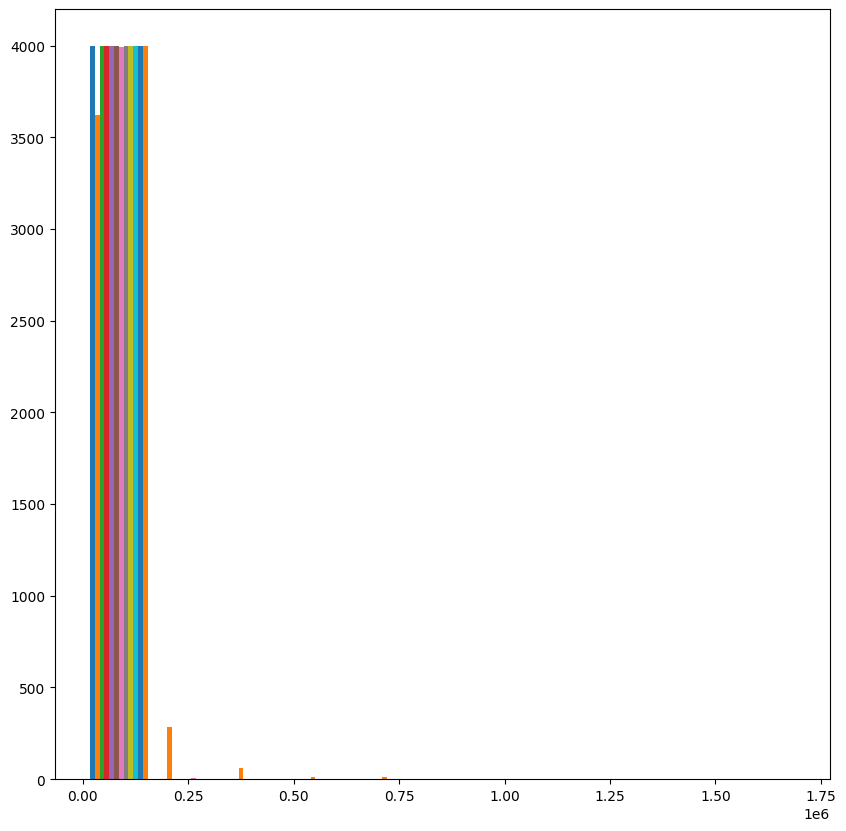

In [50]:
plt.figure(figsize=(10,10))
plt.hist(df)
plt.show()

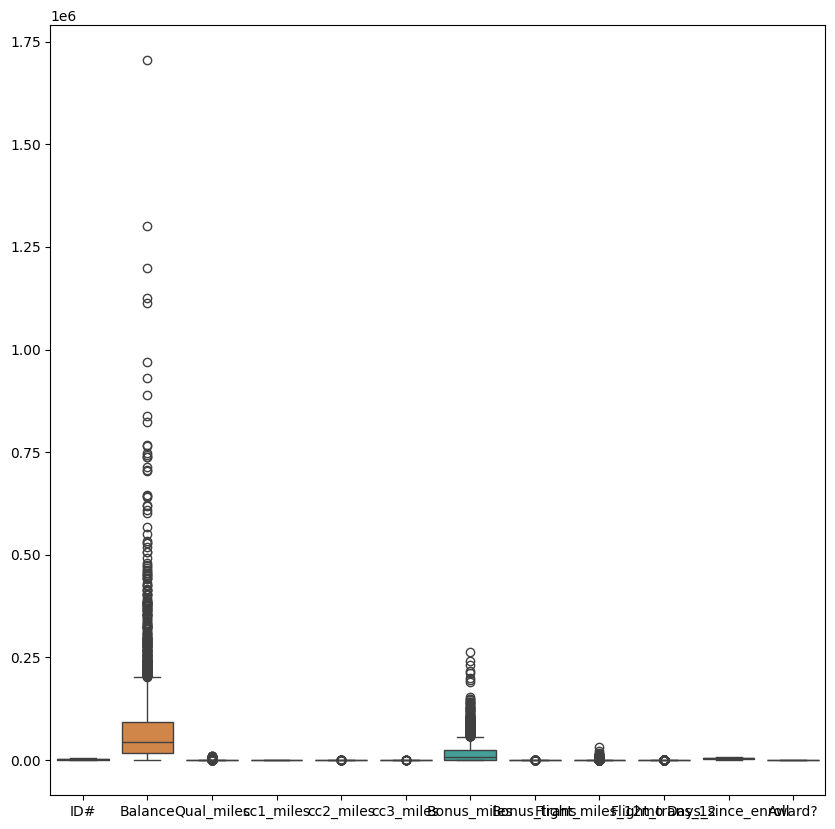

In [51]:
plt.figure(figsize=(10,10))
sns.boxplot(df)
plt.show()

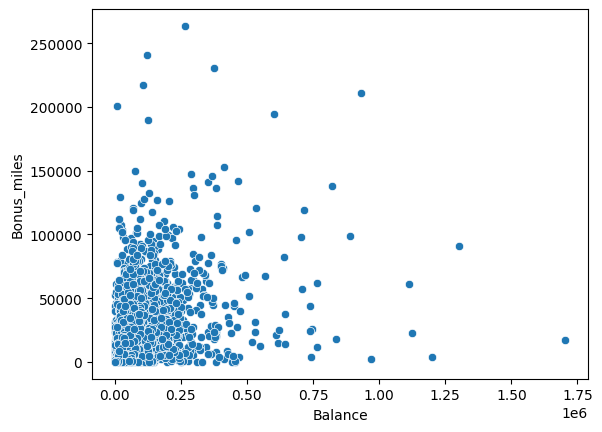

In [52]:
sns.scatterplot(data=df, x='Balance', y='Bonus_miles')
plt.show()

In [53]:
IQ3=df.quantile(0.75)
Q1=df.quantile(0.25)
IQR=IQ3-Q1
IQR

,0
ID#,2010.0
Balance,73876.5
Qual_miles,0.0
cc1_miles,2.0
cc2_miles,0.0
cc3_miles,0.0
Bonus_miles,22550.5
Bonus_trans,14.0
Flight_miles_12mo,311.0
Flight_trans_12,1.0


In [54]:
lower = Q1 - 1.5 * IQR
upper = IQ3 + 1.5 * IQR

In [55]:
lower
upper

,0
ID#,6035.50
Balance,203218.75
Qual_miles,0.00
cc1_miles,6.00
cc2_miles,1.00
cc3_miles,1.00
Bonus_miles,57626.25
Bonus_trans,38.00
Flight_miles_12mo,777.50
Flight_trans_12,2.50


In [56]:
df_clean = df[~((df < lower) | (df > upper)).any(axis=1)]


In [57]:
df_clean.shape

(2875, 12)

In [58]:
df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
scaler = StandardScaler()

In [61]:
X= df_clean.select_dtypes(include=np.number)

In [62]:
X_scaled = scaler.fit_transform(X)

In [63]:
X_scaled.shape

(2875, 12)

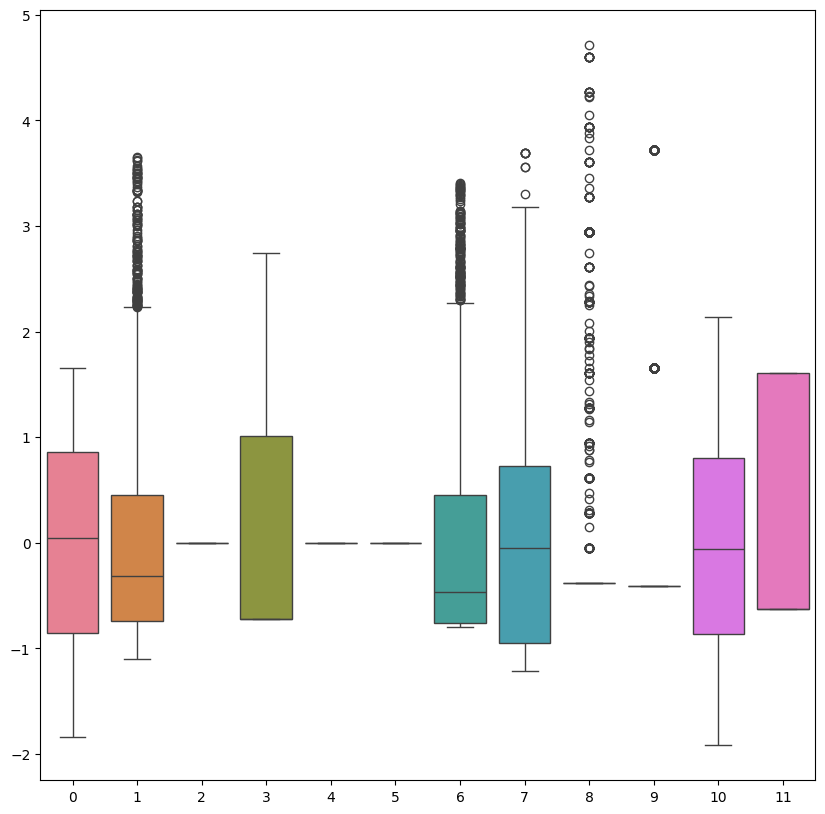

In [64]:
plt.figure(figsize=(10,10))
sns.boxplot(X_scaled)
plt.show()

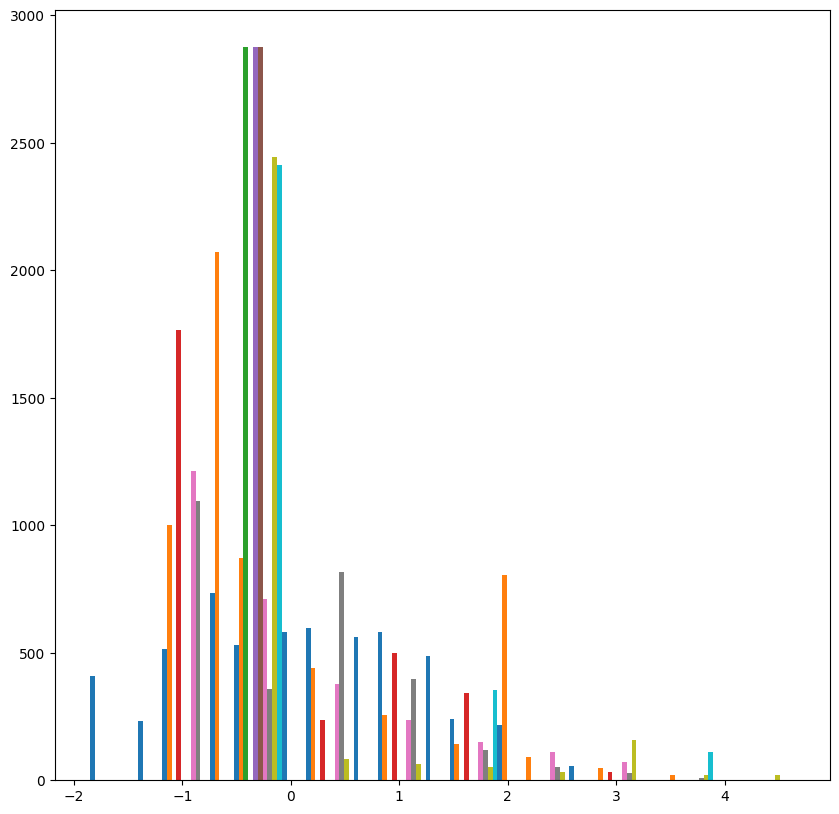

In [65]:
plt.figure(figsize=(10,10))
plt.hist(X_scaled)
plt.show()

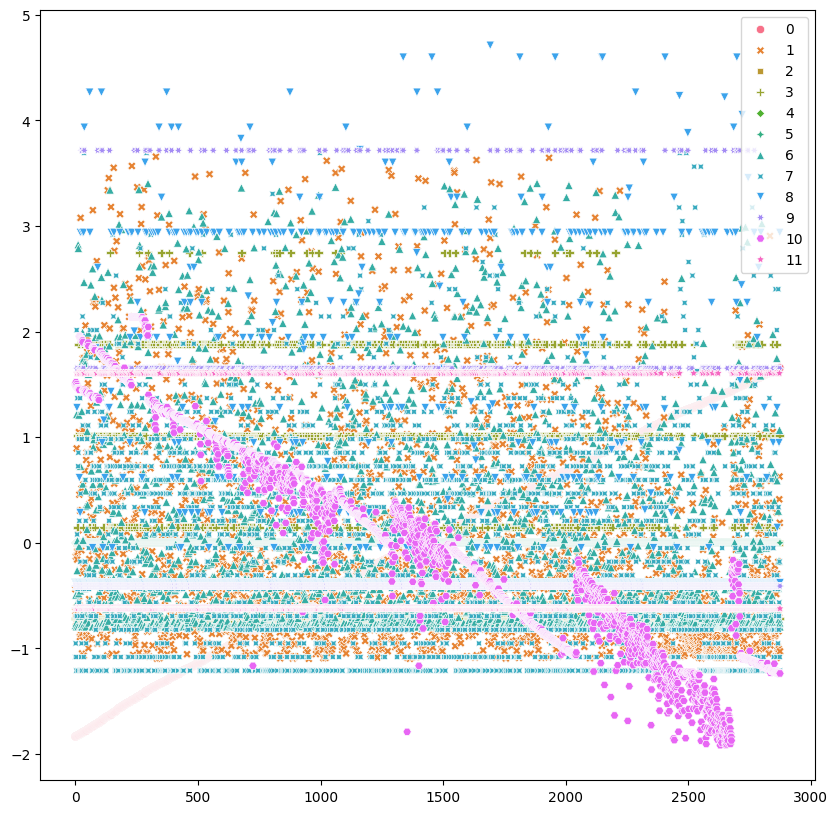

In [67]:
plt.figure(figsize=(10,10))
sns.scatterplot(X_scaled)
plt.show()

In [68]:
from sklearn.cluster import KMeans

KMeans=KMeans(n_clusters=5)
KMeans.fit(X_scaled)

KMeans(n_clusters=5)

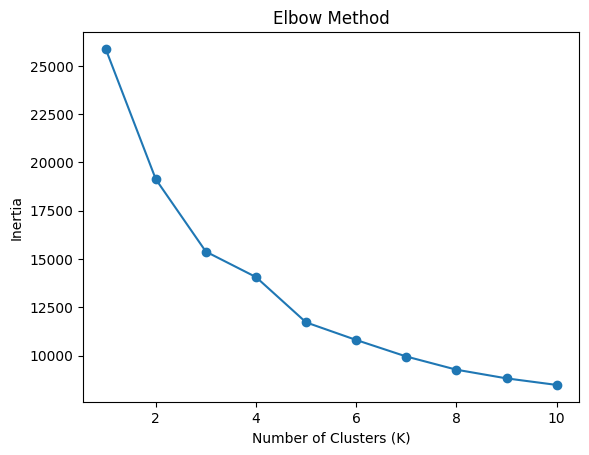

In [80]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [81]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

labels = kmeans.labels_

In [82]:
labels

array([1, 1, 1, ..., 2, 0, 1], dtype=int32)

In [84]:
import pandas as pd

pd.Series(labels).value_counts()

,count
1,1644
2,870
0,361


In [86]:
from sklearn.cluster import DBSCAN

dbscan =DBSCAN(eps=3,min_samples=4)
dbscan.fit(X_scaled)

dbscan_labels=dbscan.labels_

In [87]:
import pandas as pd

pd.Series(dbscan_labels).value_counts()

,count
0,2875


In [89]:
DBSCAN(eps=0.5,min_samples=5)
DBSCAN(eps=1,min_samples=5)
DBSCAN(eps=2,min_samples=5)
DBSCAN(eps=3,min_samples=5)

DBSCAN(eps=3)

In [91]:
for eps in [0.5,1,2,3]:
  dbscan=DBSCAN(eps=eps,min_samples=5)
  dbscan.fit(X_scaled)

  labels=dbscan.labels_

  print("eps=",eps)
  print(pd.Series(labels).value_counts())

eps= 0.5
-1     1410
 0     1117
 1       78
 5       58
 13      30
 7       25
 9       18
 20      15
 11      13
 8       12
 19      12
 21      12
 4        9
 18       8
 24       6
 14       6
 12       6
 2        5
 22       5
 6        5
 16       5
 17       5
 23       5
 3        4
 15       4
 10       2
Name: count, dtype: int64
eps= 1
 0     1748
 1      516
-1      476
 3       67
 4       15
 7       10
 2        7
 9        7
 8        7
 11       7
 6        5
 5        5
 10       5
Name: count, dtype: int64
eps= 2
 0    1805
 2     607
 3     200
 1     145
 4      53
-1      34
 5      24
 6       7
Name: count, dtype: int64
eps= 3
0    2875
Name: count, dtype: int64


In [95]:
X_scaled

array([[-1.83464329, -0.43885929,  0.        , ..., -0.40970772,
         1.50369284, -0.62307163],
       [-1.83377495, -0.64773487,  0.        , ..., -0.40970772,
         1.48803468, -0.62307163],
       [-1.83290661, -0.1287733 ,  0.        , ..., -0.40970772,
         1.52032964, -0.62307163],
       ...,
       [ 1.65435035,  0.62802805,  0.        , ..., -0.40970772,
        -1.23550729,  1.60495191],
       [ 1.65521869,  0.18915227,  0.        , ...,  1.65318143,
        -1.23599661, -0.62307163],
       [ 1.65608703, -1.02863529,  0.        , ..., -0.40970772,
        -1.23746456, -0.62307163]])

In [96]:
labels

array([0, 0, 0, ..., 0, 0, 0])

In [102]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

kmeans_labels = kmeans.labels_

In [103]:
from sklearn.metrics import silhouette_samples

silhouette_score(X_scaled,kmeans_labels)

np.float64(0.30830264215957265)

In [104]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(X_scaled)

dbscan_labels = dbscan.labels_

In [105]:
from sklearn.metrics import silhouette_score

silhouette_score(X_scaled, dbscan_labels)

np.float64(-0.33225832280910966)

In [107]:
df_clean.groupby(kmeans_labels).mean()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,2030.144044,65191.260388,0.0,2.047091,1.0,1.0,14282.160665,11.725762,421.842105,1.301939,4100.620499,0.443213
1,2350.516423,28555.939781,0.0,1.086375,1.0,1.0,2764.661800,5.359489,4.026156,0.032847,3483.546229,0.137470
2,1701.248276,73776.834483,0.0,3.144828,1.0,1.0,24780.127586,16.022989,5.995402,0.054023,4692.798851,0.480460


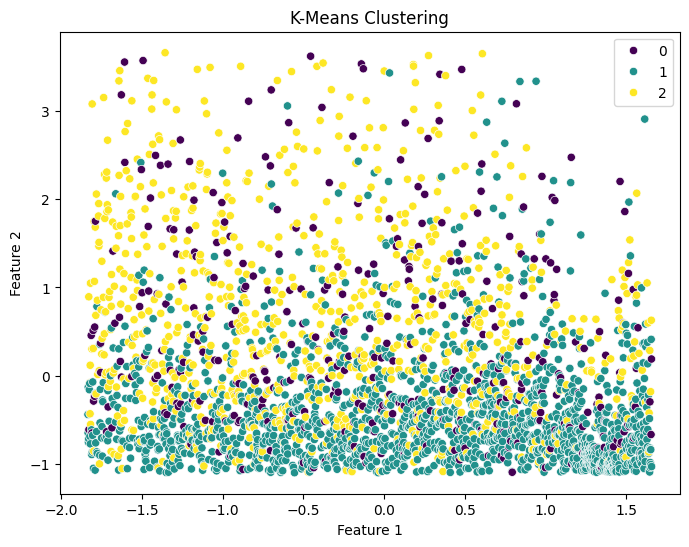

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=kmeans_labels,
    palette='viridis'
)

plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

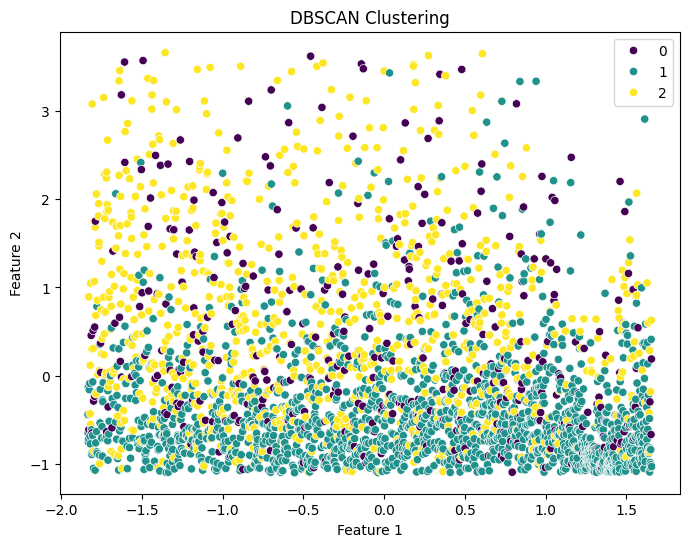

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=kmeans_labels,
    palette='viridis'
)

plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


